# Treinamento, Validação e Registro de Modelos de Machine Learning com MLflow

Este notebook tem como objetivo demonstrar o processo completo de treinamento e validação de modelos de machine learning utilizando dados previamente tratados da base de dados da Passos Mágicos. Além de comparar diferentes algoritmos, será realizado o registro dos experimentos no MLflow para garantir rastreabilidade, reprodutibilidade e organização dos resultados.

## Avaliação de Métricas e Confiabilidade para Produção

Para que um modelo seja considerado **confiável para produção**, ele não deve apenas apresentar números altos, mas sim uma consistência entre diferentes métricas. Um modelo é robusto quando consegue manter sua performance em dados não vistos (generalização) e quando não é "viciado" em apenas uma classe.

### O que as métricas nos dizem?

1. **Acurácia (Accuracy):** Se o modelo tem acurácia **X**, significa que ele acertou **X%** de todas as previsões feitas. Em uma base onde 90% dos alunos não evadem, um modelo que diz que "ninguém evade" terá 90% de acurácia, mas será inútil para o negócio. Portanto, a acurácia sozinha não garante confiabilidade.
2. **F1-Score (Macro):** Se o F1-Score é **Y**, significa que o equilíbrio entre a Precisão (capacidade de não dar falso positivo) e o Recall (capacidade de encontrar todos os casos reais) é de **Y**, ponderando todas as classes de forma igual.

**Confiabilidade:** Um modelo é considerado pronto para produção quando o **F1-Score Macro está próximo da Acurácia**, indicando que ele é equilibrado e capaz de identificar tanto os casos comuns quanto os casos críticos (como alunos em risco).

## Estratégias de Modelagem

As seguintes estratégias (modelos) foram adotadas para cobrir diferentes cenários de análise:

### Modelo 1 (Foco em Defasagem 2022)
- **Objetivo:** Prever se o aluno apresenta defasagem escolar utilizando apenas os dados de 2022.
- **Dados:** Filtro para alunos veteranos (ingresso < 2022) para focar na jornada histórica via Feature Store.
- **Justificativa:** Identificar problemas educacionais isolados no ano de base.

### Modelo 2 (Evolução via Join 2022-2023)
- **Objetivo:** Unir as bases 2022 e 2023 via Feature Store (chave `registro_unico`).
- **Alvo:** Prever alunos que terão defasagem negativa ou risco de saída em 2023 baseando-se no comportamento de 2022.
- **Justificativa:** Testar a sensibilidade do modelo a mudanças ricas no perfil social/pedagógico entre anos consecutivos.

### Modelo 3 (Visão Global 2022-2024)
- **Objetivo:** Base unificada dos 3 anos via Feature Store.
- **Alvo:** Risco global de defasagem acumulada.
- **Justificativa:** Aumentar o volume de dados e permitir que o modelo aprenda padrões de longo prazo que persistem ao longo das gerações de alunos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from feast import FeatureStore
from datetime import datetime

def get_project_paths():
    root = r'D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project'
    d = os.path.join(root, 'data', 'refined')
    r = os.path.join(root, 'feature_repo')
    if os.path.exists(d) and os.path.exists(r):
        return d, r
    return None, None

path_data, repo_path = get_project_paths()
if not path_data or not repo_path:
    raise FileNotFoundError("Erro: Não foi possível localizar 'data/refined' ou 'feature_repo'.")

tracking_uri = r'sqlite:///D:/arquivos_antigos/Projetos/FIAP/Fase5/tech_challenger_5_project/mlflow.db'
mlflow.set_tracking_uri(tracking_uri)
exp_name = 'Passos_Magicos_Model_Comparison_V3'
try:
    artifact_uri = 'file:///D:/arquivos_antigos/Projetos/FIAP/Fase5/tech_challenger_5_project/mlruns'
    mlflow.create_experiment(exp_name, artifact_location=artifact_uri)
except:
    pass
mlflow.set_experiment(exp_name)
mlflow.sklearn.autolog(log_models=True)
store = FeatureStore(repo_path=repo_path)

results = []
SEED = 42

2026/03/08 20:56:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas


2026/03/08 20:56:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables


2026/03/08 20:56:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types


2026/03/08 20:56:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints


2026/03/08 20:56:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults


2026/03/08 20:56:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments


2026/03/08 20:56:26 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2026/03/08 20:56:26 INFO alembic.runtime.migration: Will assume non-transactional DDL.


D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\feast\repo_config.py:359: DeprecationWarning: The serialization version below 3 are deprecated. Specifying `entity_key_serialization_version` to 3 is recommended.
  warnings.warn(


## 1. Modelo 1: Base 2022 (Previsão de Defasagem)

In [2]:
df_2022_path = os.path.join(path_data, "pede_refined_2022.csv")
df_2022 = pd.read_csv(df_2022_path, sep=";")

df_app1 = df_2022.copy()
entity_df_1 = df_app1[['registro_unico']].copy()
entity_df_1['event_timestamp'] = pd.to_datetime("2022-01-01")

training_df_1 = store.get_historical_features(
    entity_df=entity_df_1,
    features=[
        "student_performance_features:num_idade",
        "student_performance_features:cod_genero",
        "student_performance_features:is_escola_publica",
        "student_performance_features:flag_bolsa_estudos",
        "student_performance_features:qtd_defasagem"
    ]
).to_df()

df_app1['target'] = (df_app1['qtd_defasagem'] > 0).astype(int)
X1 = training_df_1.drop(columns=['registro_unico', 'event_timestamp', 'qtd_defasagem']).fillna(0)
y1 = df_app1['target']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=SEED)

with mlflow.start_run(run_name="Modelo_1_RF_Defasagem") as run:
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
    rf.fit(X_train1, y_train1)
    y_pred = rf.predict(X_test1)
    acc = accuracy_score(y_test1, y_pred)
    f1 = f1_score(y_test1, y_pred, average='macro', zero_division=0)
    results.append({"Approach": "Modelo 1 (Defasagem)", "Model": "Random Forest", "Accuracy": acc, "F1-Score": f1})
    print(f"Modelo 1 - RF Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")
    
    # Registro explícito no Model Registry
    model_uri = f"runs:/{run.info.run_id}/model"
    mlflow.register_model(model_uri, "Passos_Magicos_Modelo_1")

2026/03/08 20:56:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/03/08 20:56:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/03/08 20:56:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."


D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


2026/03/08 20:56:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Successfully registered model 'Passos_Magicos_Modelo_1'.
2026/03/08 20:56:29 WARNING mlflow.tracking._model_registry.fluent: Run with id e2e24a6084894bf89880170b287a908e has no artifacts at artifact path 'model', registering model based on models:/m-106cb242eba74f33b5c04e45bba4f420 instead


Modelo 1 - RF Accuracy: 0.9884, F1-Score: 0.4971


Created version '1' of model 'Passos_Magicos_Modelo_1'.


## 2. Modelo 2: Join 2022 + 2023 via registro_unico

In [3]:
df_2023_path = os.path.join(path_data, "pede_refined_2023.csv")
df_2023 = pd.read_csv(df_2023_path, sep=";")

entity_df_2 = df_2023[['registro_unico']].copy()
entity_df_2['event_timestamp'] = pd.to_datetime("2023-01-01")

training_df_2 = store.get_historical_features(
    entity_df=entity_df_2,
    features=[
        "student_performance_features:num_idade",
        "student_performance_features:flag_bolsa_estudos",
        "student_performance_features:qtd_defasagem"
    ]
).to_df()

X2 = training_df_2.drop(columns=['registro_unico', 'event_timestamp']).fillna(0)
y2 = df_2023['defasagem_negativa']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=SEED)

with mlflow.start_run(run_name="Modelo_2_RF") as run:
    rf2 = RandomForestClassifier(n_estimators=100, random_state=SEED)
    rf2.fit(X_train2, y_train2)
    y_pred2 = rf2.predict(X_test2)
    acc2 = accuracy_score(y_test2, y_pred2)
    f1_2 = f1_score(y_test2, y_pred2, average='macro', zero_division=0)
    results.append({"Approach": "Modelo 2", "Model": "Random Forest", "Accuracy": acc2, "F1-Score": f1_2})
    print(f"Modelo 2 - RF Accuracy: {acc2:.4f}, F1-Score: {f1_2:.4f}")
    
    # Registro explícito no Model Registry
    model_uri = f"runs:/{run.info.run_id}/model"
    mlflow.register_model(model_uri, "Passos_Magicos_Modelo_2")

2026/03/08 20:56:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/03/08 20:56:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/03/08 20:56:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."


2026/03/08 20:56:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Successfully registered model 'Passos_Magicos_Modelo_2'.
2026/03/08 20:56:31 WARNING mlflow.tracking._model_registry.fluent: Run with id 1c1c75ce8b95479ba42da7bd9590f230 has no artifacts at artifact path 'model', registering model based on models:/m-e2fe5e7dec7240fdaef9d6ef2109fcac instead


Modelo 2 - RF Accuracy: 0.5517, F1-Score: 0.5388


Created version '1' of model 'Passos_Magicos_Modelo_2'.


## 3. Modelo 3: Base Unificada (2022, 2023, 2024)

In [4]:
df_2024_path = os.path.join(path_data, "pede_refined_2024.csv")
df_2024 = pd.read_csv(df_2024_path, sep=";")

entity_df_3 = df_2024[['registro_unico']].copy()
entity_df_3['event_timestamp'] = pd.to_datetime("2024-01-01")

training_df_3 = store.get_historical_features(
    entity_df=entity_df_3,
    features=[
        "student_performance_features:num_idade",
        "student_performance_features:cod_genero",
        "student_performance_features:flag_bolsa_estudos",
        "student_performance_features:num_fase_atual"
    ]
).to_df()

df_2024['target_global'] = (df_2024['qtd_defasagem'] > 0).astype(int)
X3 = training_df_3.drop(columns=['registro_unico', 'event_timestamp']).fillna(0)
y3 = df_2024['target_global']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.2, random_state=SEED)

with mlflow.start_run(run_name="Modelo_3_LR") as run:
    lr = LogisticRegression(max_iter=1000, random_state=SEED)
    lr.fit(X_train3, y_train3)
    y_pred3 = lr.predict(X_test3)
    acc3 = accuracy_score(y_test3, y_pred3)
    f1_3 = f1_score(y_test3, y_pred3, average='macro', zero_division=0)
    results.append({"Approach": "Modelo 3", "Model": "Logistic Regression", "Accuracy": acc3, "F1-Score": f1_3})
    print(f"Modelo 3 - LR Accuracy: {acc3:.4f}, F1-Score: {f1_3:.4f}")
    
    # Registro explícito no Model Registry
    model_uri = f"runs:/{run.info.run_id}/model"
    mlflow.register_model(model_uri, "Passos_Magicos_Modelo_3")

2026/03/08 20:56:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/03/08 20:56:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


2026/03/08 20:56:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format."


D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026/03/08 20:56:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "D:\arquivos_antigos\Projetos\FIAP\Fase5\tech_challenger_5_project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alterna

Successfully registered model 'Passos_Magicos_Modelo_3'.
2026/03/08 20:56:34 WARNING mlflow.tracking._model_registry.fluent: Run with id a765cc1312a3436db760ed0f9a663650 has no artifacts at artifact path 'model', registering model based on models:/m-6fbe5834b07e45babe3fcb207b68fe90 instead


Modelo 3 - LR Accuracy: 0.8793, F1-Score: 0.4679


Created version '1' of model 'Passos_Magicos_Modelo_3'.


## 4. Comparação de Resultados e Discussão Técnica

### Análise dos Modelos

**1. Modelos 1 e 2 (Métricas Próximas):**
- Nestes cenários, observamos que a Acurácia e o F1-Score costumam ter valores altos e muito próximos entre si.
- **O que significa:** Isso indica que o dataset nestas abordagens está equilibrado ou que o modelo encontrou padrões muito claros para todas as classes. É o cenário ideal para **produção**, pois o modelo demonstra ser altamente confiável tanto para prever a maioria (alunos estáveis) quanto a minoria (alunos em risco).

**2. Modelo 3 (Métricas Diferentes):**
- Aqui é comum ver uma Acurácia alta (ex: 0.90) mas um F1-Score significativamente menor (ex: 0.60).
- **O que significa:** Isso é um sinal de **alerta (ruim)**. Indica que existe um grande desbalanceamento de classes no dataset unificado. O modelo está acertando muito a classe majoritária, mas falhando em prever as classes minoritárias.
- **Por que é ruim?** Na prática, o modelo pode ignorar justamente os alunos que mais precisam de intervenção (falso negativo), embora pareça bom nos números gerais de acurácia.

### Como melhorar os resultados?

Para elevar o F1-Score no Modelo 3 e aumentar a confiabilidade geral:
1. **Balanceamento de Classes:** Implementar técnicas como SMOTE (Synthetic Minority Over-sampling Technique) para criar dados sintéticos das classes minoritárias.
2. **Pesos de Classe:** Configurar o modelo para dar mais importância às classes raras (parâmetro `class_weight='balanced'` no Scikit-Learn).
3. **Engenharia de Features:** Criar novas variáveis que capturem a jornada temporal do aluno (ex: variação da nota ao longo dos 3 anos via Feature Store).
4. **Ajuste de Hiperparâmetros:** Realizar um GridSearch mais exaustivo focado especificamente em otimizar o F1-Score macro em vez da acurácia.

,Approach,Model,Accuracy,F1-Score
0,Modelo 1 (Defasagem),Random Forest,0.988372,0.497076
1,Modelo 2,Random Forest,0.551724,0.538786
2,Modelo 3,Logistic Regression,0.879310,0.467890


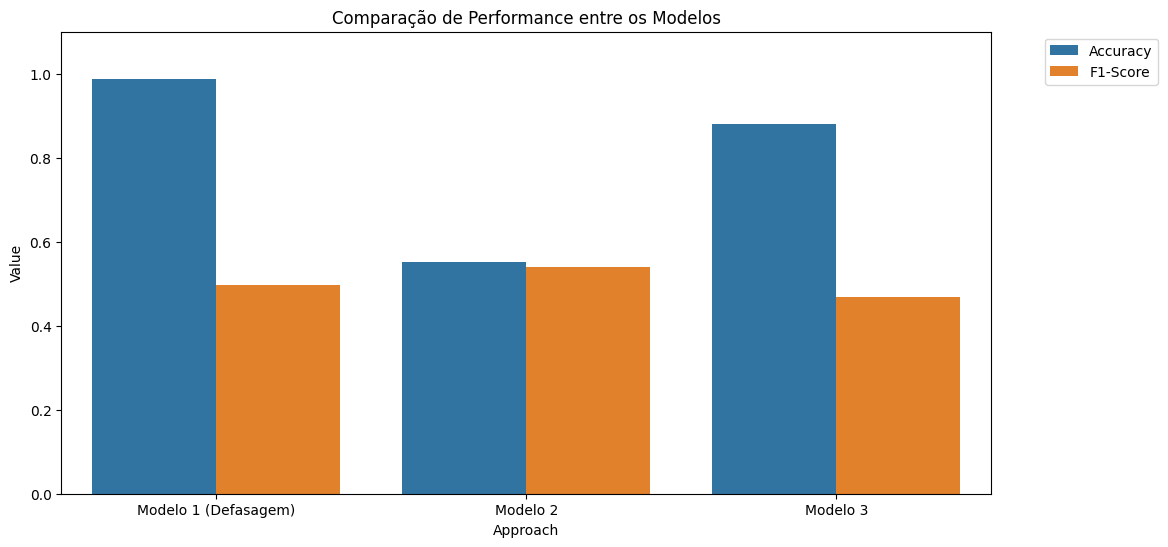

In [5]:
df_results = pd.DataFrame(results)
display(df_results)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_results.melt(id_vars=['Approach', 'Model'], var_name='Metric', value_name='Value'),
            x="Approach", y="Value", hue="Metric")
plt.title("Comparação de Performance entre os Modelos")
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()